# Reproduction of m2lines L96 results
The goal of this notebook is to successfully reproduce the results of the first section of m2lines L96 model website. These code blocks will then be used as copyable snippets for further development down the line.


We are directly choosing to work with the single time-scale model. This means skipping over the two time-scale model. Stochasticity and architectural inductive biases are also skipped for now.

The equation of the model is as follows:
$$ \frac{dX_k}{dt} = (X_{k+1} - X_{k-2})X_{k-1} - X_k + F - \frac{hc}{b} \sum_{j=0}^{J-1} Y_{j,k} $$

Where $k = 1,2,...,K$ and $j = 1,2,...,J$.

The last term represents the coupling between the slow variables $X_k$ and the fast variables $Y_{j,k}$. This coupling $\frac{hc}{b} \sum_{j=0}^{J-1} Y_{j,k}$ is defined as $U_k$. We say $U_k \equiv P(X_k)$, where $P$ is a parameterization function in terms of $X_k$.

In [19]:
import sys
import os

current_dir = os.path.abspath(os.getcwd())
parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from src.l96_model import L96_eq1_xdot
from src.l96_model import L96

Define GCM that solves for temporal evolution of Xs using a simple Euler integration method.

In [21]:
def GCM(X0, F, dt, nt, param=[0]):
    '''X0: initial state of the system, shape (K,)
       F: forcing term, scalar
       dt: time step
       nt: number of time steps
       param: model parameters'''
    time, hist, X = dt * np.arange(nt), np.zeros((nt, len(X0))) * np.nan, X0.copy()

    for n in range(nt):
        X = X + dt * (L96_eq1_xdot(X, F) - np.polyval(param, X))
        if np.abs(X).max() > 1e3:
            print(f"Warning: X diverged at time step {n}.")
            break
        hist[n], time[n] = X, dt * (n + 1)
    return hist, time

In [22]:
np.random.seed(23)
W = L96(8, 32)
T = 5.0
X_true, Y_true, t = W.run(0.05, T)

In [23]:
X_init, dt, F_model = X_true[0], 0.002, W.F #dt set less because Euler scheme is less accurate than RK4. F_model is the forcing term used in the L96 model.

X_gcm_no_param, T_gcm_no_param = GCM(X_init, F_model, dt, int(T/dt))

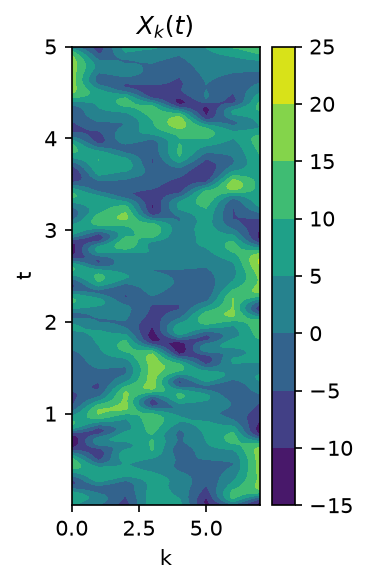

In [24]:
plt.figure(figsize=(2.5, 4), dpi=150)

plt.subplot(111)
plt.contourf(W.k, T_gcm_no_param, X_gcm_no_param)
plt.colorbar()
plt.xlabel("k")
plt.ylabel("t")
plt.title("$X_k(t)$")

plt.tight_layout()

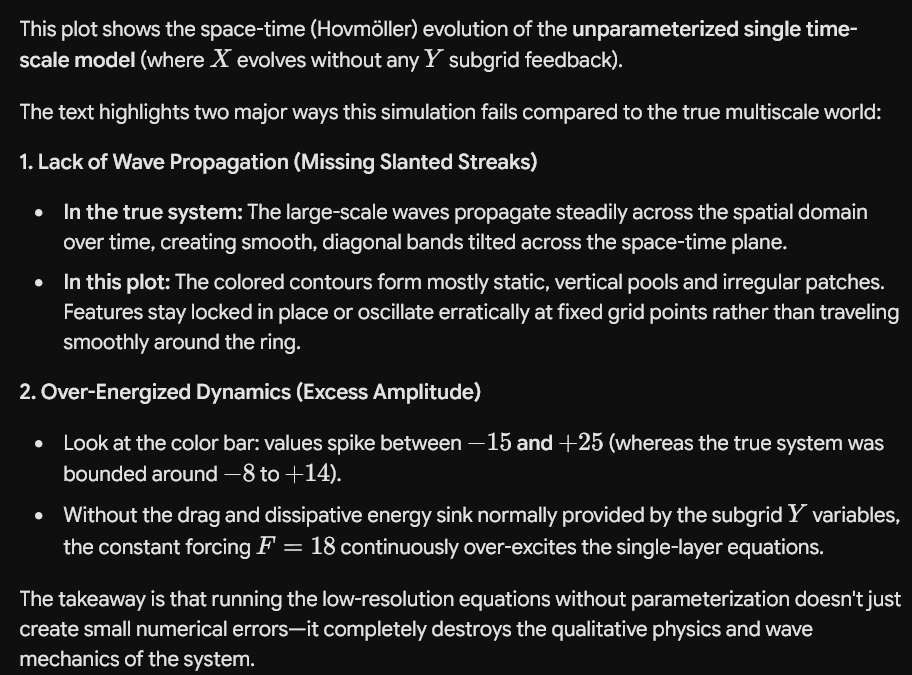

# TODO: @Vyoor Update this file more